# 02 · Segmentation Visualizer — U-Net, Baseline vs. Optimized (test set)

Visual inspection of the lesion masks predicted on the **held-out test set** (1,000 official ISIC 2018 Task 1
test images, never seen before Phase 5). Each row shows, for one test image:

| Column | Content |
|---|---|
| 1 · Image | the dermoscopy image as stored by Phase 0 (dataset resolution) |
| 2 · Ground truth | the official ISIC annotation (green fill, solid border) |
| 3 · Baseline | ground truth and Baseline prediction overlaid (Phase 1 model) |
| 4 · Optimized | ground truth and Optimized prediction overlaid (Phase 4 model) |

Predictions come from the Baseline (Phase 1) and the Optimized (Phase 4) U-Net. The U-Net predicts at 256×256; its probability map
is upsampled bilinearly to the image's dataset resolution (longer side ≤ 1,024 px) and thresholded at 0.5 — exactly the mask that was scored. Overlays are drawn on a lightened greyscale copy of
the image so the colours stay readable on dark lesions:

| Overlay | Meaning | Secondary cue (colour-vision safe) |
|---|---|---|
| green  | ground truth only (missed lesion, FN) | solid outline = ground-truth border |
| red    | prediction only (false positive, FP) | dashed outline = predicted border |
| yellow | ground truth ∩ prediction (TP) | — |

**Inputs** (written by `run_pipeline_unet.sh --phases 5`; no training, no GPU):
`phase5_test/per_image/<variant>_<model>_fp32.csv` (per-image DSC/JSI) and
`phase5_test/masks/<variant>_<model>/<image>.png` (predicted masks, FP32). The ground truth is read with the same
function used for the metrics (`unet/segmentation_metrics.py`, byte-identical in the three repositories), so what
you see is exactly what was scored. The YOLO26 dataset is located automatically (Docker mount, `datasets/`, or
`../sandbox_yolo26/datasets/`). This notebook is identical in the YOLO26, U-Net and SAM 3 repositories except for
the model-specific loading cell.

In [1]:
# ---- Configuration ----------------------------------------------------------
PIPELINE_NAME = "pipeline_final_v1"   # sub-directory of logs/ (or set $PIPELINE_DIR)
MODEL = "unet"                        # the U-Net pipeline has a single model
PRECISION = "fp32"                    # masks are saved for FP32 only
N_SAMPLES = 6                         # random test images to show
N_EXTREMES = 4                        # rows in the "largest gain / regression / hardest" panels
SEED = 0                              # reproducible sampling

# Overlay colours (requested: GT green, prediction red; overlap yellow) + outline styles
GT_COLOR, PRED_COLOR, OVERLAP_COLOR = "#00c853", "#ff1744", "#ffd600"
ALPHA = 0.40


import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Locate the repository and the pipeline outputs ------------------------
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()


def find_pipeline_dir(name: str) -> Path | None:
    """$PIPELINE_DIR, else the Docker mount, else <repo>/logs/<name>; None if none exists yet."""
    candidates = [os.environ.get("PIPELINE_DIR"), f"/workspace/logs/{name}", REPO_ROOT / "logs" / name]
    for c in candidates:
        if c and Path(c).is_dir():
            return Path(c)
    print(f"[info] pipeline outputs not found; tried {candidates}. Set PIPELINE_DIR.")
    return None


#: Where the YOLO26 dataset (images + labels, the source of truth) may live on the host.
YOLO_DATASET_CANDIDATES = [REPO_ROOT / "datasets" / "isic2018_task1_official",
                           REPO_ROOT.parent / "sandbox_yolo26" / "datasets" / "isic2018_task1_official",
                           # earlier export (results produced before the official-release rebuild)
                           REPO_ROOT / "datasets" / "isic_2018_task1_yolo26",
                           REPO_ROOT.parent / "sandbox_yolo26" / "datasets" / "isic_2018_task1_yolo26"]


def local_path(p) -> Path:
    """Map /workspace/... paths recorded inside Docker to this machine when run on the host."""
    p = Path(p)
    if p.exists():
        return p
    s = str(p)
    for prefix in ("/workspace/yolo26_dataset/", "/workspace/datasets/isic2018_task1_official/",
                   "/workspace/datasets/isic_2018_task1_yolo26/"):
        if s.startswith(prefix):
            for root in YOLO_DATASET_CANDIDATES:
                if (root / s[len(prefix):]).exists():
                    return root / s[len(prefix):]
    if s.startswith("/workspace/") and (REPO_ROOT / p.relative_to("/workspace")).exists():
        return REPO_ROOT / p.relative_to("/workspace")
    return p


PHASE5_MISSING = "⚠️ Phase 5 results not yet generated. Training is likely still in progress. Skipping cell execution."
PHASE5_READY = False   # set by the data-loading cell; every later cell is skipped while it is False
PIPELINE_DIR = find_pipeline_dir(PIPELINE_NAME) or REPO_ROOT / "logs" / PIPELINE_NAME
FIG_DIR = PIPELINE_DIR / "figures"

# ---- Figure style (publication, light) -------------------------------------
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#ffffff"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "axes.edgecolor": INK_2, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "legend.frameon": False, "legend.fontsize": 8, "lines.linewidth": 2, "lines.markersize": 7,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})


def save(fig, name: str) -> None:
    """Save a figure as vector PDF (for LaTeX) and 300-dpi PNG under <pipeline>/figures/."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=300)
    print(f"saved {FIG_DIR / name}.pdf|png")


print("pipeline :", PIPELINE_DIR)
print("figures  :", FIG_DIR)

pipeline : /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1
figures  : /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures


In [2]:
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:   # OpenCV missing in this kernel → the mask figures are skipped with a message, not crashed
    import cv2
    sys.path.insert(0, str(REPO_ROOT / "unet"))
    from segmentation_metrics import ground_truth_mask  # noqa: E402
    MISSING_DEPS = None
except ImportError as err:
    MISSING_DEPS = str(err)

VARIANTS = ("baseline", "optimized")
PER_IMAGE = PIPELINE_DIR / "phase5_test" / "per_image"

available = sorted({p.stem.split("_")[1] for p in PER_IMAGE.glob(f"*_{PRECISION}.csv")})
if available and MODEL not in available:
    print(f"[info] no Phase 5 results for MODEL={MODEL!r}; available: {available}")
    MODEL = available[0]
    print(f"[info] using MODEL={MODEL!r}")
PHASE5_READY = bool(available) and all((PER_IMAGE / f"{v}_{MODEL}_{PRECISION}.csv").exists() for v in VARIANTS)
if not PHASE5_READY:
    print(PHASE5_MISSING)
elif MISSING_DEPS:
    PHASE5_READY = False
    print(f"⚠️ {MISSING_DEPS}: OpenCV is needed to draw the masks (pip install opencv-python-headless). Skipping the figures.")
else:
    def load_variant(variant: str) -> pd.DataFrame:
        df = pd.read_csv(PER_IMAGE / f"{variant}_{MODEL}_{PRECISION}.csv")
        return df[["image", "dsc", "jsi", "n_pred", "empty_pred"]].rename(
            columns=lambda c: c if c == "image" else f"{c}_{variant}")


    per_image = load_variant("baseline").merge(load_variant("optimized"), on="image", validate="one_to_one")
    per_image["delta_dsc"] = per_image["dsc_optimized"] - per_image["dsc_baseline"]

    mask_dirs = {v: PIPELINE_DIR / "phase5_test" / "masks" / f"{v}_{MODEL}" for v in VARIANTS}
    missing = [str(d) for d in mask_dirs.values() if not d.is_dir()]
    if missing:
        print(f"⚠️ Predicted masks not found: {missing}. Re-run Phase 5a without --no-save-masks. Skipping the figures.")
        PHASE5_READY = False

    MODEL_LABEL = "U-Net"


    def load_gt(image: str, h: int, w: int) -> np.ndarray:
        """Official ISIC mask (masks/<id>.png of the shared YOLO26 Phase 0 dataset), exactly as scored."""
        return ground_truth_mask(local_path(image), h, w)


    summary = pd.DataFrame({
        v: {"mean DSC": per_image[f"dsc_{v}"].mean(), "mean JSI": per_image[f"jsi_{v}"].mean(),
            "empty predictions": int(per_image[f"empty_pred_{v}"].sum())}
        for v in VARIANTS
    })
    print(f"model={MODEL}  test images={len(per_image)}  "
          f"improved={(per_image.delta_dsc > 0).sum()}  worse={(per_image.delta_dsc < 0).sum()}")
    display(summary.round(4))

model=unet  test images=1000  improved=444  worse=556


,baseline,optimized
mean DSC,0.8692,0.8706
mean JSI,0.7974,0.7951
empty predictions,0.0000,2.0000


In [3]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    def load_image(image: str) -> np.ndarray:
        img = cv2.imread(str(local_path(image)))
        if img is None:
            raise FileNotFoundError(local_path(image))
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    def load_pred(variant: str, image: str) -> np.ndarray:
        m = cv2.imread(str(mask_dirs[variant] / f"{Path(image).stem}.png"), cv2.IMREAD_GRAYSCALE)
        return m > 127


    def lightened(img: np.ndarray) -> np.ndarray:
        # Overlays are drawn on a lightened greyscale copy so the fill colours read true on dark
        # lesions (yellow over dark brown would turn olive); the colour original is in column 1.
        grey = img.astype(float).mean(axis=2, keepdims=True) / 255
        return np.repeat(0.4 + 0.6 * grey, 3, axis=2)


    def ground_truth_panel(ax, img: np.ndarray, gt: np.ndarray) -> None:
        out = lightened(img)
        out[gt] = (1 - ALPHA) * out[gt] + ALPHA * np.array(to_rgb(GT_COLOR))
        ax.imshow(out)
        if gt.any():
            ax.contour(gt.astype(float), levels=[0.5], colors=[GT_COLOR], linewidths=1.2, linestyles="solid")
        ax.set_title("Ground truth", fontsize=8)
        ax.axis("off")


    def overlay(ax, img: np.ndarray, gt: np.ndarray, pred: np.ndarray, title: str) -> None:
        out = lightened(img)
        for region, color in ((gt & ~pred, GT_COLOR), (pred & ~gt, PRED_COLOR), (gt & pred, OVERLAP_COLOR)):
            out[region] = (1 - ALPHA) * out[region] + ALPHA * np.array(to_rgb(color))
        ax.imshow(out)
        if gt.any():
            ax.contour(gt.astype(float), levels=[0.5], colors=[GT_COLOR], linewidths=1.2, linestyles="solid")
        if pred.any():
            ax.contour(pred.astype(float), levels=[0.5], colors=[PRED_COLOR], linewidths=1.2, linestyles="dashed")
        ax.set_title(title, fontsize=8)
        ax.axis("off")


    LEGEND = [
        Patch(facecolor=GT_COLOR, alpha=ALPHA, edgecolor=GT_COLOR, label="Ground truth only (FN) — solid border"),
        Patch(facecolor=PRED_COLOR, alpha=ALPHA, edgecolor=PRED_COLOR, label="Prediction only (FP) — dashed border"),
        Patch(facecolor=OVERLAP_COLOR, alpha=ALPHA, edgecolor=OVERLAP_COLOR, label="Overlap (TP)"),
    ]


    def show_rows(rows: pd.DataFrame, heading: str, fname: str) -> None:
        """One row per test image: image | ground truth | Baseline overlay | Optimized overlay."""
        fig, axes = plt.subplots(len(rows), 4, figsize=(7.2, 2.0 * len(rows)), squeeze=False)
        for ax_row, (_, r) in zip(axes, rows.iterrows()):
            img = load_image(r.image)
            gt = load_gt(r.image, *img.shape[:2])
            ax_row[0].imshow(img)
            ax_row[0].set_title(Path(r.image).stem[:28], fontsize=8)
            ax_row[0].axis("off")
            ground_truth_panel(ax_row[1], img, gt)
            for ax, v in zip(ax_row[2:], VARIANTS):
                overlay(ax, img, gt, load_pred(v, r.image),
                        f"{v.capitalize()}\nDSC {r[f'dsc_{v}']:.3f} · JSI {r[f'jsi_{v}']:.3f}")
        fig.suptitle(f"{heading} — {MODEL_LABEL}, test set", x=0.01, ha="left", fontweight="semibold")
        fig.legend(handles=LEGEND, loc="lower center", ncol=3, fontsize=7, bbox_to_anchor=(0.5, -0.02))
        fig.tight_layout(rect=(0, 0.03, 1, 0.98))
        save(fig, fname)
        plt.show()

## Random test images
A seeded random sample (`SEED`), so the same images are shown on every run.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.
findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/seg_random_unet.pdf|png


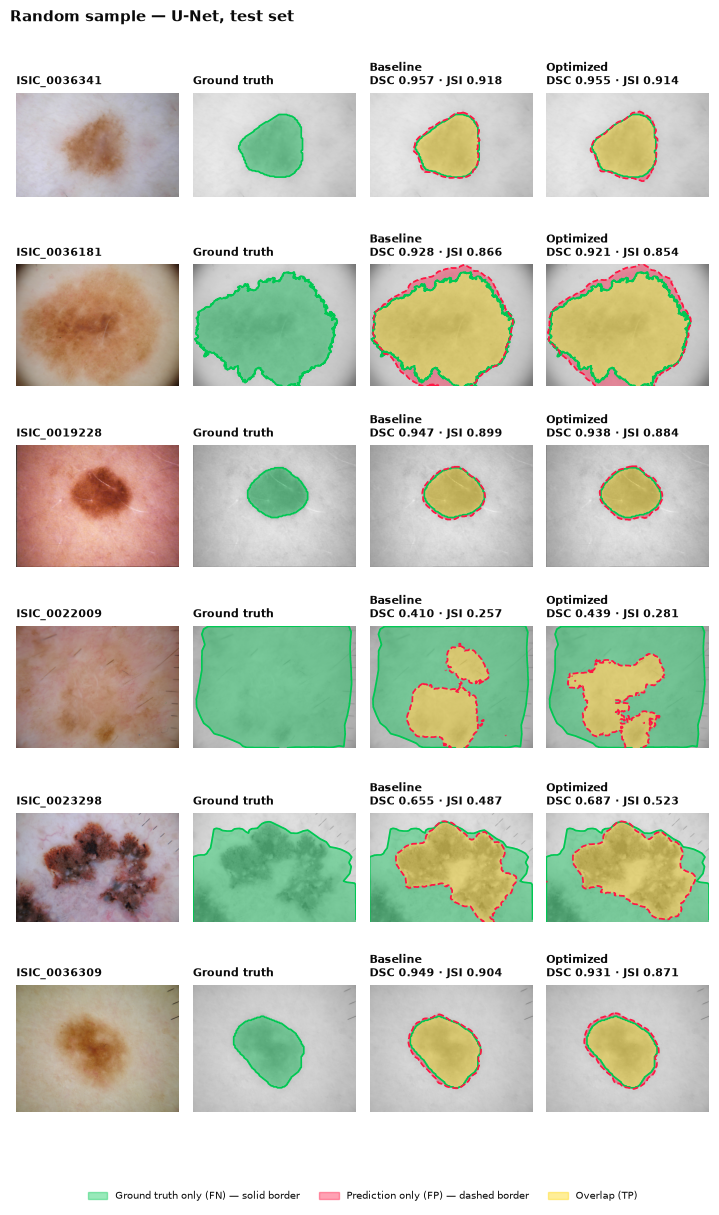

In [4]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    sample = per_image.sample(n=min(N_SAMPLES, len(per_image)), random_state=SEED)
    show_rows(sample, "Random sample", f"seg_random_{MODEL}")

## Where HPO helped most
Largest per-image DSC gains (Optimized − Baseline).

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/seg_gains_unet.pdf|png


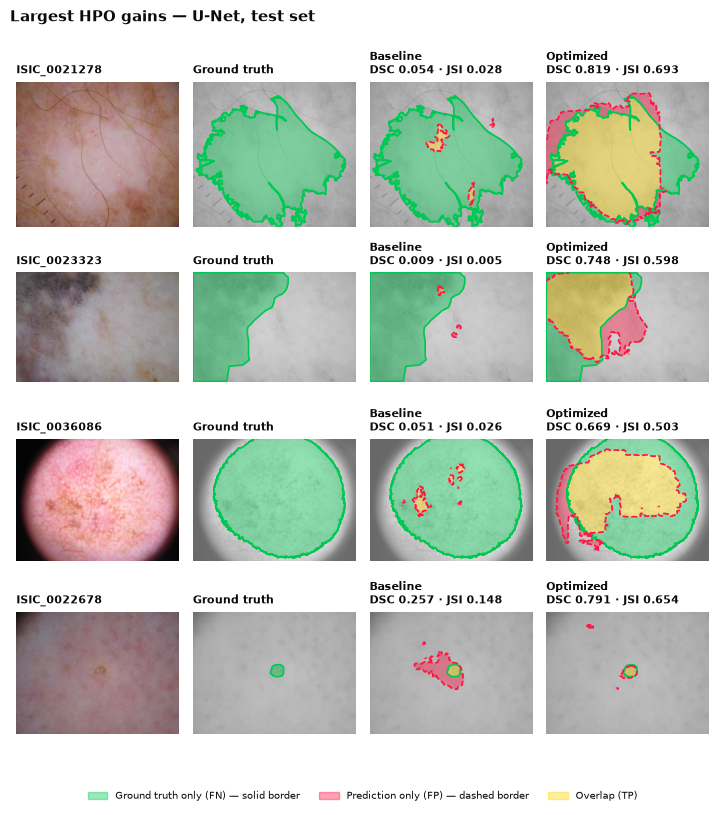

In [5]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    show_rows(per_image.nlargest(min(N_EXTREMES, len(per_image)), "delta_dsc"), "Largest HPO gains", f"seg_gains_{MODEL}")

## Where HPO hurt most
Largest per-image DSC regressions — useful to check whether the optimized model trades robustness for average accuracy.

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/seg_regressions_unet.pdf|png


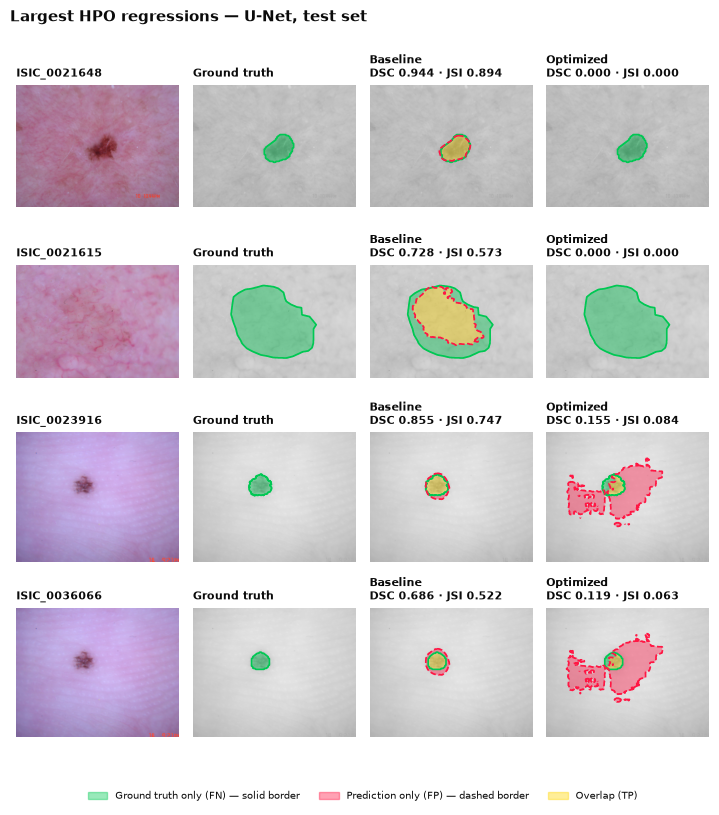

In [6]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    show_rows(per_image.nsmallest(min(N_EXTREMES, len(per_image)), "delta_dsc"), "Largest HPO regressions", f"seg_regressions_{MODEL}")

## Hardest images for the optimized model
Lowest optimized DSC — failure analysis (low contrast, hair, artefacts, very large/small lesions).

saved /home/antoniovinicius/projects/sandbox_unet/logs/pipeline_final_v1/figures/seg_hardest_unet.pdf|png


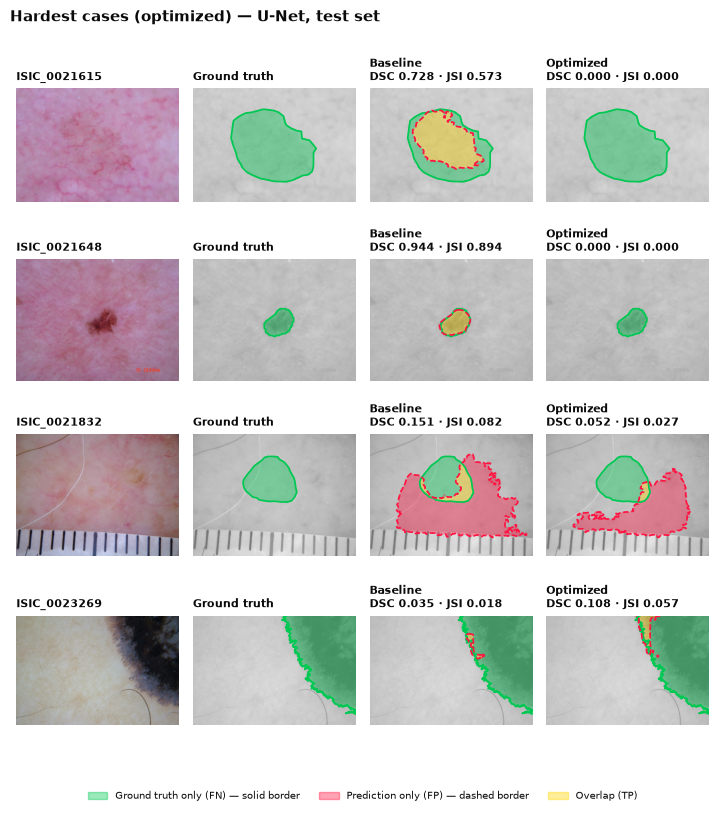

In [7]:
if not PHASE5_READY:
    print(PHASE5_MISSING)
else:
    show_rows(per_image.nsmallest(min(N_EXTREMES, len(per_image)), "dsc_optimized"), "Hardest cases (optimized)", f"seg_hardest_{MODEL}")